# MODULE 6 FINAL PROJECT - Temporal Churn Prediction

##### Executive Summary

This project develops a temporal machine learning system for predicting customer churn in FitPulse, a subscription-based fitness application. The goal of the project is to identify customers who are likely to disengage and churn within the next eight weeks using historical behavioral and engagement data collected over time.

A synthetic temporal dataset containing weekly customer activity records was designed to simulate realistic user engagement patterns, inactivity trends, payment behavior, and workout activity. The project focuses on temporal churn prediction rather than static classification because customer behavior evolves gradually before churn occurs.

Multiple machine learning models were developed and evaluated, including Logistic Regression, Decision Tree, Random Forest, and XGBoost. The final XGBoost model achieved the strongest predictive performance with high ROC-AUC and balanced precision-recall performance. Additional analyses including threshold optimization, explainability, calibration analysis, and customer risk segmentation were also performed to support business decision-making and deployment readiness.

The final churn prediction system demonstrates how temporal machine learning can help subscription-based businesses proactively identify at-risk customers, improve retention strategies, and support data-driven operational decision-making.

---

##### Business Problem Definition

FitPulse is a subscription-based fitness application experiencing customer churn, where users gradually reduce engagement and eventually stop using the platform. The business challenge is not only identifying which users may churn, but detecting churn behavior early enough for the company to intervene before customers are lost.

A temporal churn prediction system is necessary because customer behavior changes over time. Users typically do not churn suddenly. Instead, they show warning signs such as reduced workouts, fewer app sessions, declining streak activity, increasing inactivity, payment issues, and lower engagement patterns over several weeks. A static prediction model would fail to capture these evolving behavioral trends.

The primary users of this system are the marketing, customer retention, and product teams. The model supports these teams by identifying high-risk customers and helping prioritize retention campaigns, personalized notifications, promotional offers, and re-engagement strategies.

It is important to distinguish between predicting churn and preventing churn. Predicting churn refers to estimating the probability that a customer may leave the platform in the future. Preventing churn refers to the business actions taken after prediction, such as targeted interventions and retention campaigns designed to improve customer engagement.

The overall business objective is to reduce customer attrition, improve retention rates, increase customer lifetime value, and support long-term subscription revenue growth.

---

##### Temporal Dataset Construction

A synthetic temporal dataset was designed for this project to simulate realistic customer behavior within the FitPulse platform. The dataset contains weekly behavioral records for 5,000 users observed across 52 weeks, resulting in 260,000 total observations.

The dataset includes repeated user-level observations over time, allowing the project to model how engagement patterns evolve before churn occurs. Weekly granularity was selected because fitness engagement behavior generally changes over multiple weeks rather than daily.

The dataset includes several behavioral and engagement-related variables, including:

- App sessions
- Workouts completed
- Average session duration
- Streak days
- Payment failures
- Support tickets
- Push notification clicks
- Days since last workout
- Rolling engagement metrics
- Trend-based activity indicators

To improve realism, the dataset intentionally includes:
- Missing values
- Class imbalance
- Behavioral variability
- Temporal engagement fluctuations
- Gradual decline patterns before churn

Several assumptions were made while constructing the dataset. The project assumes that declining engagement, increasing inactivity, and payment-related issues are strong indicators of future churn behavior. It is also assumed that customer behavior remains relatively stable within shorter time periods.

Potential limitations of the dataset include:
- Synthetic behavior may not perfectly represent real-world customers
- Certain churn patterns may be simplified
- Demographic diversity may not fully reflect actual populations
- Simulated relationships may introduce modeling bias

Despite these limitations, the dataset provides a strong foundation for developing and evaluating a realistic temporal churn prediction system.

---

##### Defining Customer Churn

For the FitPulse business scenario, churn is defined as a customer becoming inactive and disengaged from the platform within a future 8-week period. Instead of relying only on account cancellation, this project focuses on behavioral churn, where users gradually reduce engagement before leaving the platform.

The target variable used in this project is `churn_next_8_weeks`, which identifies whether a customer is expected to churn within the next eight weeks based on current and historical behavioral patterns.

An 8-week prediction horizon was selected because it provides the business with sufficient lead time to take preventive action before customers fully disengage. A shorter horizon may not provide enough time for intervention strategies, while a significantly longer horizon could reduce prediction accuracy and operational usefulness.

This churn definition aligns with the business goals of subscription-based platforms, where early detection of disengagement enables retention teams to intervene through personalized notifications, workout recommendations, promotional offers, and customer support outreach.

---

##### Import Libraries

This section imports all required Python libraries used throughout the project. The libraries support data manipulation, visualization, machine learning, model evaluation, explainability, and deployment preparation. These tools are necessary for building a complete temporal churn prediction pipeline from data analysis to production-ready model saving.

In [25]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and validation
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.calibration import calibration_curve

# Utilities
import shap
import joblib

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Additional plotting tools
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Global palette
PALETTE = [
    '#1B4F72',
    '#2E86AB',
    '#F39C12',
    '#E74C3C',
    '#27AE60',
    '#8E44AD',
    '#F1948A',
    '#85C1E9'
]

# Theme settings
sns.set_theme(
    style='whitegrid',
    font_scale=1.1
)

plt.rcParams.update({
    'figure.dpi': 120
})

print("All libraries imported successfully.")

All libraries imported successfully.


##### Load Dataset

This section loads the temporal churn dataset into the notebook and converts the date column into a datetime format. Converting dates is important because this project uses time-based analysis and temporal validation techniques that rely on proper chronological ordering.

In [26]:
# Load dataset
df = pd.read_csv(
    "fitness_temporal_churn_dataset.csv"
)

# Convert date column
df["week_date"] = pd.to_datetime(df["week_date"])

##### Initial Inspection

This section explores the overall structure and quality of the dataset. The analysis includes checking the dataset shape, viewing sample records, identifying data types, detecting missing values, and understanding the temporal coverage of the data. This helps ensure the dataset is suitable for temporal churn modeling.

In [27]:
# Dataset overview
print("Dataset Shape:")
print(df.shape)

# Preview data
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:
(260000, 18)

First 5 Rows:
  user_id  week_date  week_number subscription_plan age_group  app_sessions  \
0  U00001 2025-01-06            1             Basic     26-35             8   
1  U00001 2025-01-13            2             Basic     26-35             6   
2  U00001 2025-01-20            3             Basic     26-35             8   
3  U00001 2025-01-27            4             Basic     26-35             6   
4  U00001 2025-02-03            5             Basic     26-35             6   

   workouts_completed  avg_session_minutes  streak_days  payment_failures  \
0                   2                 21.8           19                 0   
1                   4                 30.6           19                 0   
2                   5                 30.5           21                 0   
3                   3                 29.9           20                 0   
4                   3                 43.0           20                 0   

   support_tickets 

##### Dataset Information

This section displays detailed information about the dataset, including column names, data types, and non-null counts. Understanding the structure of the dataset is necessary for identifying numerical, categorical, and temporal variables. This also helps determine which preprocessing methods and machine learning techniques will be appropriate later in the project.

In [28]:
# Data types and nulls
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260000 entries, 0 to 259999
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   user_id                   260000 non-null  object        
 1   week_date                 260000 non-null  datetime64[ns]
 2   week_number               260000 non-null  int64         
 3   subscription_plan         260000 non-null  object        
 4   age_group                 260000 non-null  object        
 5   app_sessions              260000 non-null  int64         
 6   workouts_completed        260000 non-null  int64         
 7   avg_session_minutes       254866 non-null  float64       
 8   streak_days               260000 non-null  int64         
 9   payment_failures          260000 non-null  int64         
 10  support_tickets           260000 non-null  int64         
 11  push_notification_clicks  260000 non-null  int64         
 12  da

##### Missing Values

This section checks for missing values across all columns in the dataset and calculates the percentage of missing data.

In [29]:
# Missing value summary
missing_values = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percent": round(
        (df.isnull().sum() / len(df)) * 100,
        2
    )
})

missing_values = missing_values[
    missing_values["Missing_Count"] > 0
]

print(missing_values)

                     Missing_Count  Missing_Percent
avg_session_minutes           5134             1.97


##### Duplicate Rows

This section checks whether duplicate observations exist in the dataset.

In [30]:
# Check duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


##### Descriptive Statistics

This section generates descriptive statistics for both numerical and categorical variables in the dataset.

In [31]:
# Descriptive statistics - Numerical
print(df.describe().round(2))

                           week_date  week_number  app_sessions  \
count                         260000    260000.00     260000.00   
mean   2025-07-03 11:59:59.999999744        26.50          8.42   
min              2025-01-06 00:00:00         1.00          0.00   
25%              2025-04-05 06:00:00        13.75          6.00   
50%              2025-07-03 12:00:00        26.50          9.00   
75%              2025-09-30 18:00:00        39.25         11.00   
max              2025-12-29 00:00:00        52.00         22.00   
std                              NaN        15.01          3.90   

       workouts_completed  avg_session_minutes  streak_days  payment_failures  \
count           260000.00            254866.00    260000.00         260000.00   
mean                 2.83                32.88        13.41              0.09   
min                  0.00                 1.00         0.00              0.00   
25%                  2.00                27.70         6.00             

In [32]:
# Descriptive statistics - Categorical
print(df.describe(include="object"))

       user_id subscription_plan age_group
count   260000            260000    260000
unique    5000                 2         4
top     U00001             Basic     26-35
freq        52            183560    107172


##### Unique Users & Time Coverage

This section examines the number of unique users and the overall temporal coverage of the dataset. Understanding the time range and number of unique periods also helps validate the dataset structure.

In [33]:
# Temporal structure

print("Unique Users:")
print(df["user_id"].nunique())

print("\nDate Range:")
print(df["week_date"].min())
print(df["week_date"].max())

print("\nUnique Weeks:")
print(df["week_date"].nunique())

Unique Users:
5000

Date Range:
2025-01-06 00:00:00
2025-12-29 00:00:00

Unique Weeks:
52


##### Churn Distribution

This section analyzes the distribution of the target variable, churn_next_8_weeks. Understanding class balance is important because churn prediction problems are typically imbalanced, with fewer churners than retained users. This analysis helps determine whether imbalance handling techniques such as SMOTE are necessary during model training.

In [34]:
# Target variable distribution
print(df["churn_next_8_weeks"].value_counts())

print("\nPercentage Distribution:")

print(
    round(
        df["churn_next_8_weeks"]
        .value_counts(normalize=True) * 100,
        2
    )
)

churn_next_8_weeks
0    251200
1      8800
Name: count, dtype: int64

Percentage Distribution:
churn_next_8_weeks
0    96.62
1     3.38
Name: proportion, dtype: float64


##### Weekly Churn Trend Over Time

This section visualizes how churn rates change over time across different weeks in the dataset. This analysis supports the business objective of understanding when churn behavior emerges rather than treating churn as a static event.

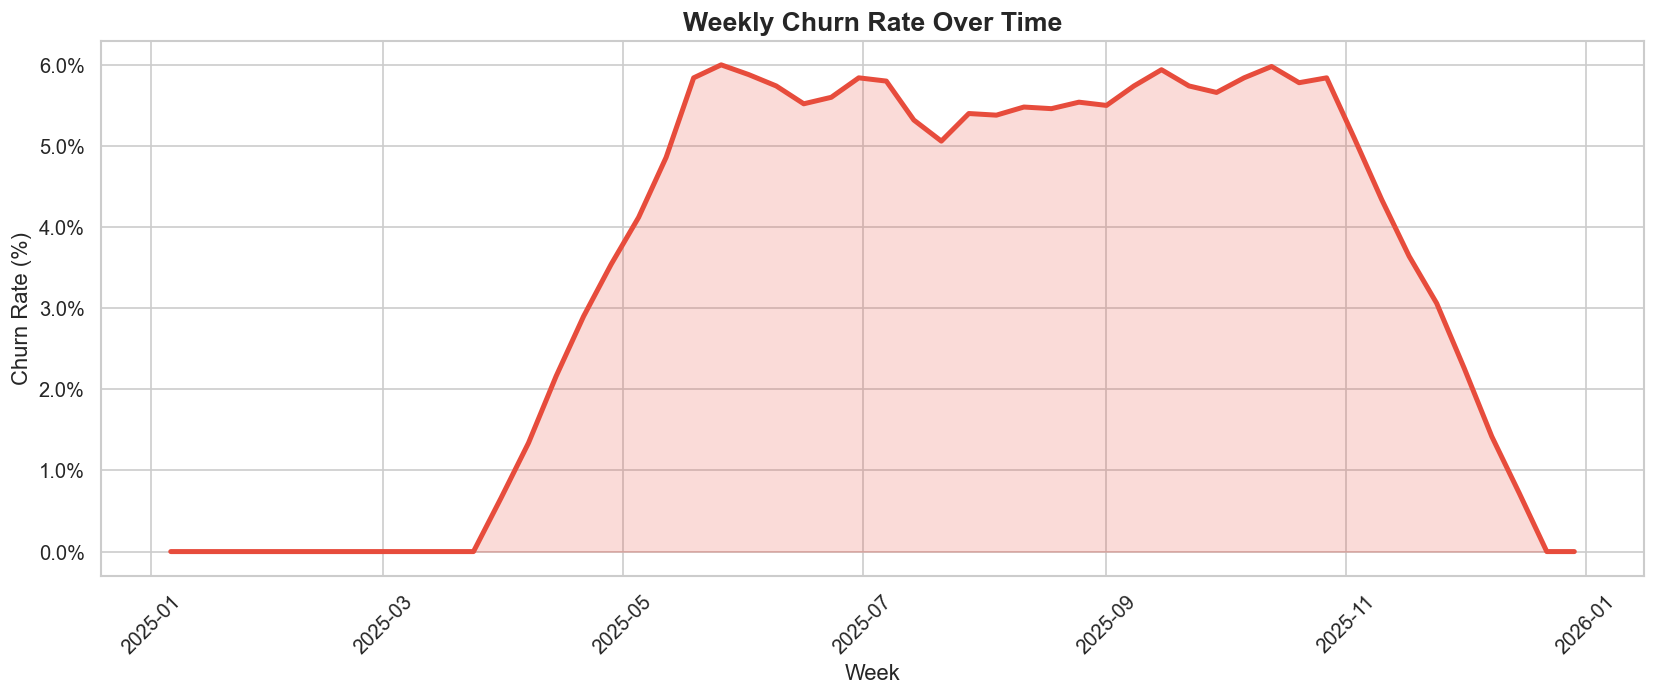

In [35]:
# Weekly churn trend

weekly_churn = (
    df.groupby("week_date")["churn_next_8_weeks"]
    .mean()
    .reset_index()
)

weekly_churn["churn_rate_percent"] = (
    weekly_churn["churn_next_8_weeks"] * 100
)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    weekly_churn["week_date"],
    weekly_churn["churn_rate_percent"],
    color=PALETTE[3],
    linewidth=3
)

ax.fill_between(
    weekly_churn["week_date"],
    weekly_churn["churn_rate_percent"],
    alpha=0.2,
    color=PALETTE[3]
)

ax.set_title(
    "Weekly Churn Rate Over Time",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("Week")
ax.set_ylabel("Churn Rate (%)")

ax.yaxis.set_major_formatter(
    mticker.PercentFormatter()
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### Churners vs Non-Churners - Engagement Trend

This section compares app session activity between future churners and retained users over time. The visualization helps identify behavioral divergence patterns that emerge before churn occurs. Understanding engagement decline is important because it allows the business to detect early warning signals and intervene before users leave the platform.

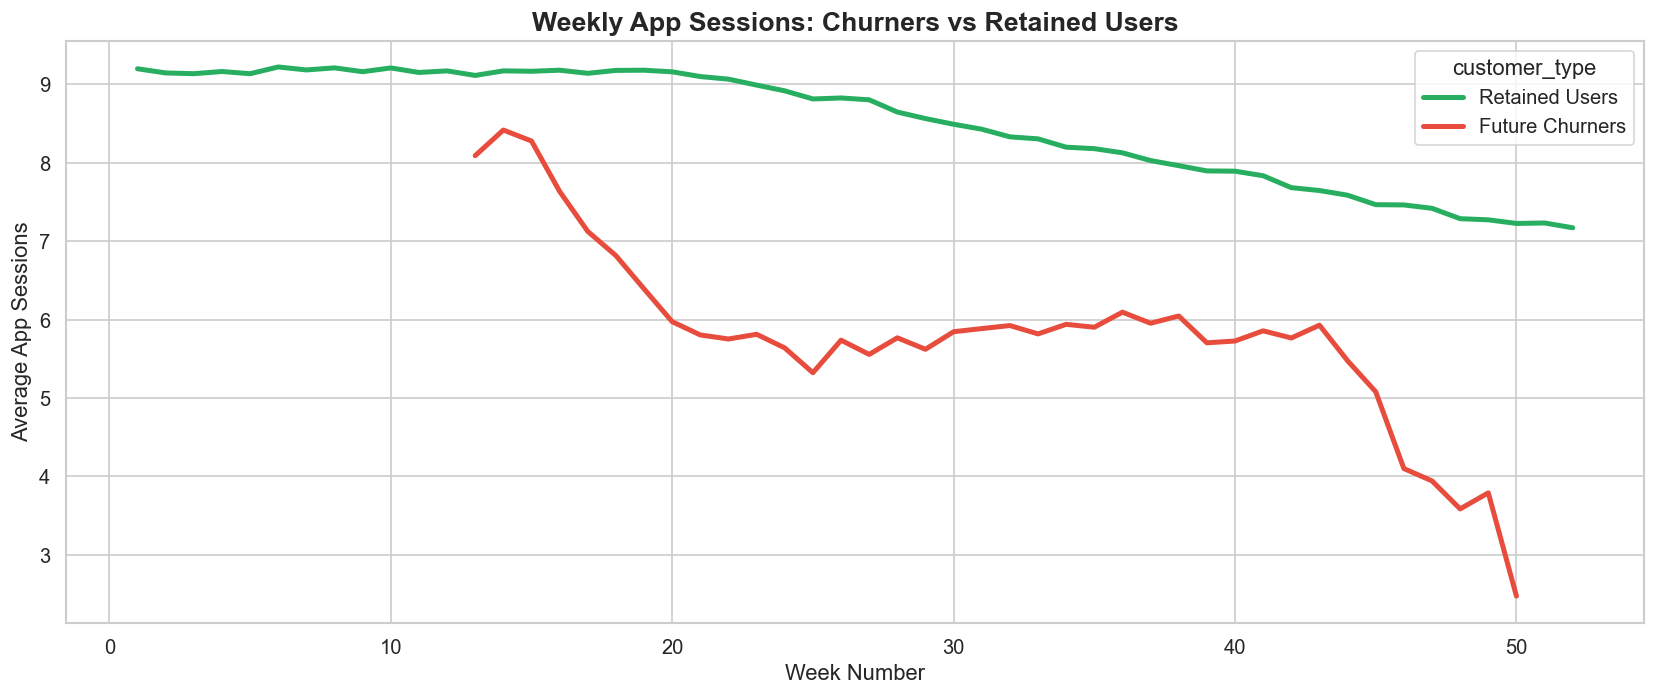

In [36]:
# App sessions: Churner vs non-churners over time

sessions_trend = (
    df.groupby(
        ["week_number", "churn_next_8_weeks"]
    )["app_sessions"]
    .mean()
    .reset_index()
)

# Rename labels
sessions_trend["customer_type"] = (
    sessions_trend["churn_next_8_weeks"]
    .map({
        0: "Retained Users",
        1: "Future Churners"
    })
)

# Print values
# print(sessions_trend.round(2))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=sessions_trend,
    x="week_number",
    y="app_sessions",
    hue="customer_type",
    palette=[PALETTE[4], PALETTE[3]],
    linewidth=3,
    ax=ax
)

ax.set_title(
    "Weekly App Sessions: Churners vs Retained Users",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("Week Number")
ax.set_ylabel("Average App Sessions")

plt.tight_layout()
plt.show()

##### Workouts Trend Over Time

This section analyzes workout completion trends for churners and non-churners across multiple weeks. The goal is to examine whether declining workout activity is associated with future churn behavior. This analysis helps determine whether engagement-related features are strong predictors for churn prediction models.

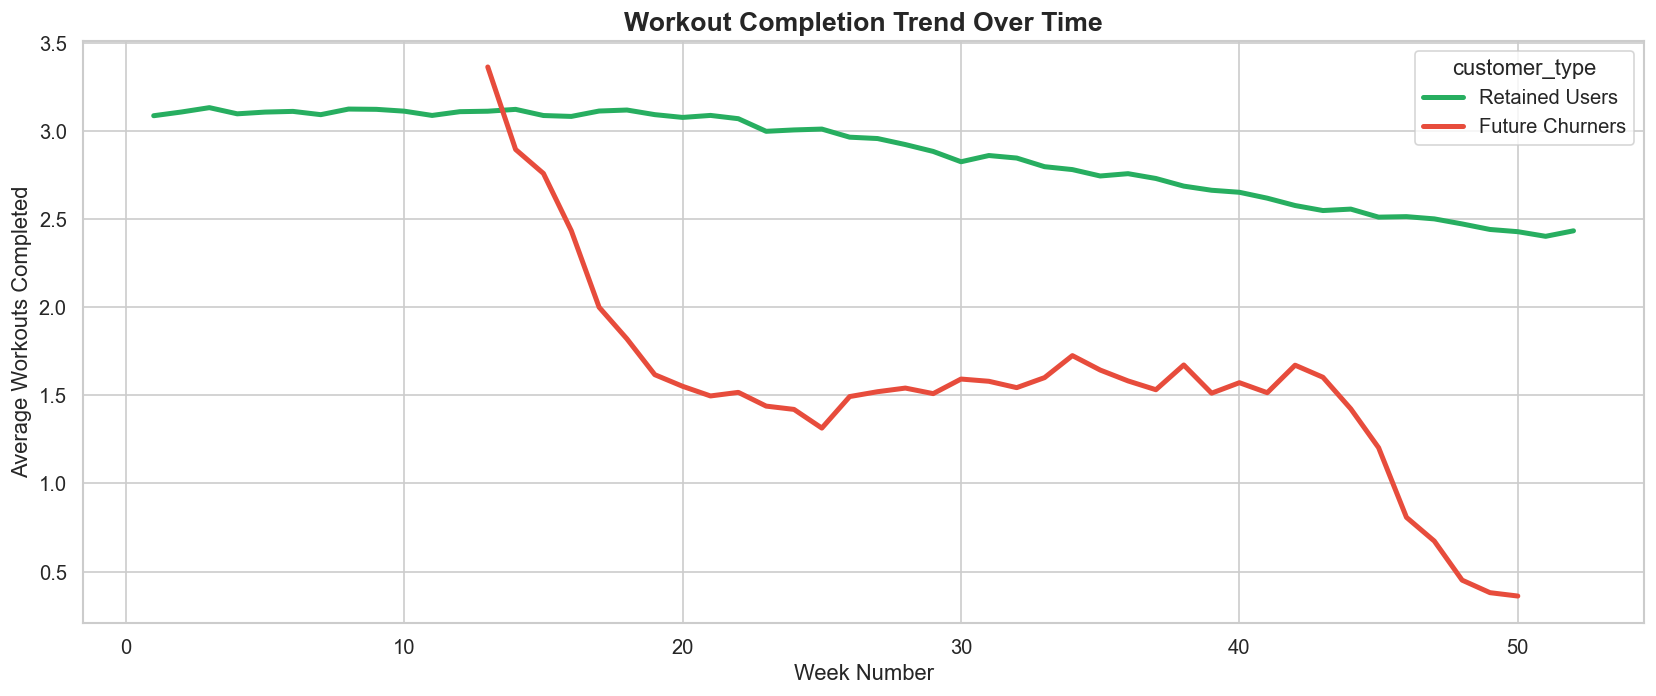

In [37]:
# Workout trend: Churner vs non-churners

workout_trend = (
    df.groupby(
        ["week_number", "churn_next_8_weeks"]
    )["workouts_completed"]
    .mean()
    .reset_index()
)

workout_trend["customer_type"] = (
    workout_trend["churn_next_8_weeks"]
    .map({
        0: "Retained Users",
        1: "Future Churners"
    })
)

# Print values
# print(workout_trend.round(2))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=workout_trend,
    x="week_number",
    y="workouts_completed",
    hue="customer_type",
    palette=[PALETTE[4], PALETTE[3]],
    linewidth=3,
    ax=ax
)

ax.set_title(
    "Workout Completion Trend Over Time",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("Week Number")
ax.set_ylabel("Average Workouts Completed")

plt.tight_layout()
plt.show()

##### Inactivity Trend

This section studies inactivity behavior by analyzing the number of days since the last workout for churners and retained users. Increasing inactivity is often an early signal of customer disengagement in fitness applications. Understanding these trends helps support the creation of recency-based churn features later in the project.

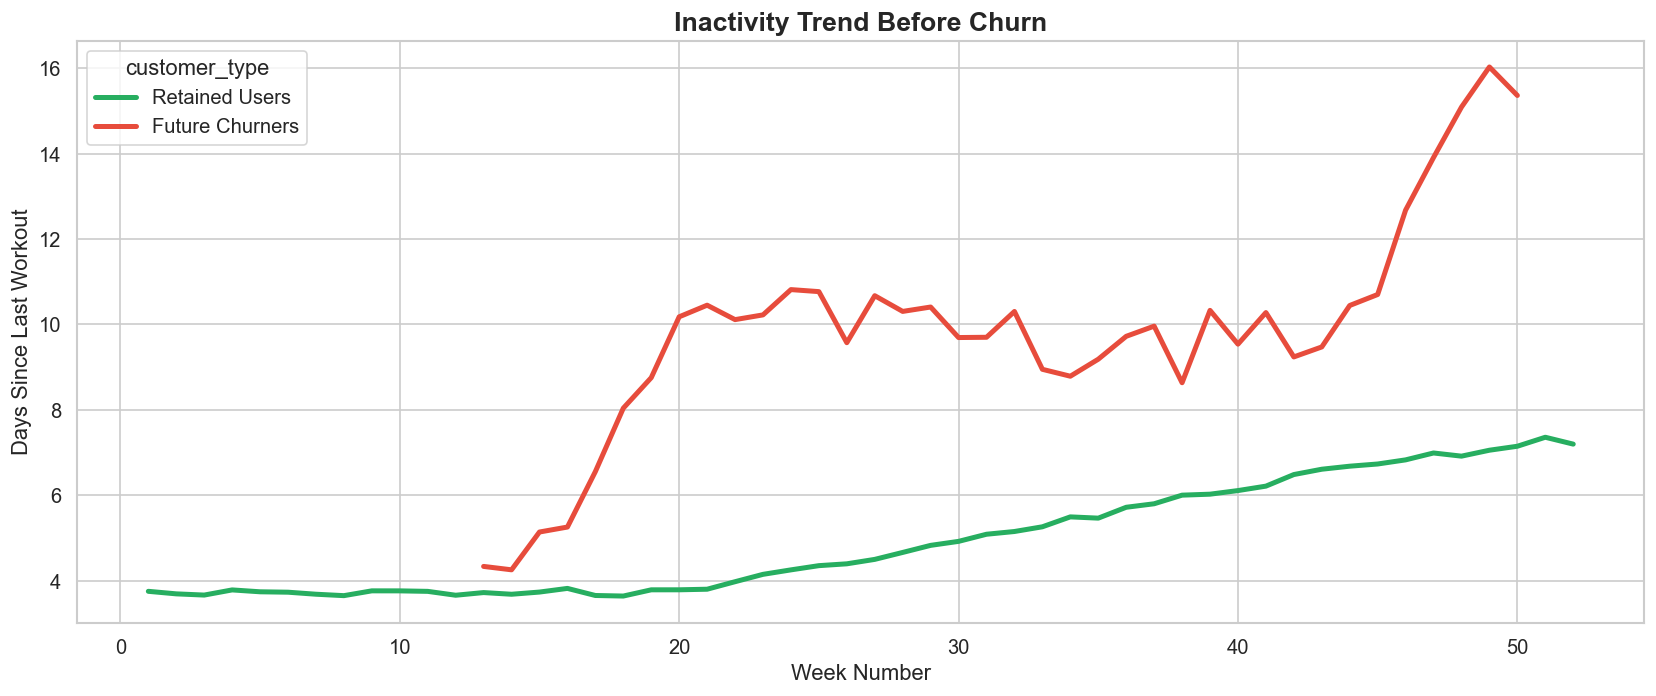

In [38]:
# Inactivity trend

inactive_trend = (
    df.groupby(
        ["week_number", "churn_next_8_weeks"]
    )["days_since_last_workout"]
    .mean()
    .reset_index()
)

inactive_trend["customer_type"] = (
    inactive_trend["churn_next_8_weeks"]
    .map({
        0: "Retained Users",
        1: "Future Churners"
    })
)

# Print values
# print(inactive_trend.round(2))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=inactive_trend,
    x="week_number",
    y="days_since_last_workout",
    hue="customer_type",
    palette=[PALETTE[4], PALETTE[3]],
    linewidth=3,
    ax=ax
)

ax.set_title(
    "Inactivity Trend Before Churn",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("Week Number")
ax.set_ylabel("Days Since Last Workout")

plt.tight_layout()
plt.show()

##### Subscription Plan vs Churn

This section compares churn behavior across different subscription plans. The visualization helps determine whether certain plan types experience higher churn rates than others. These insights can support targeted retention strategies and help the business identify high-risk customer segments.

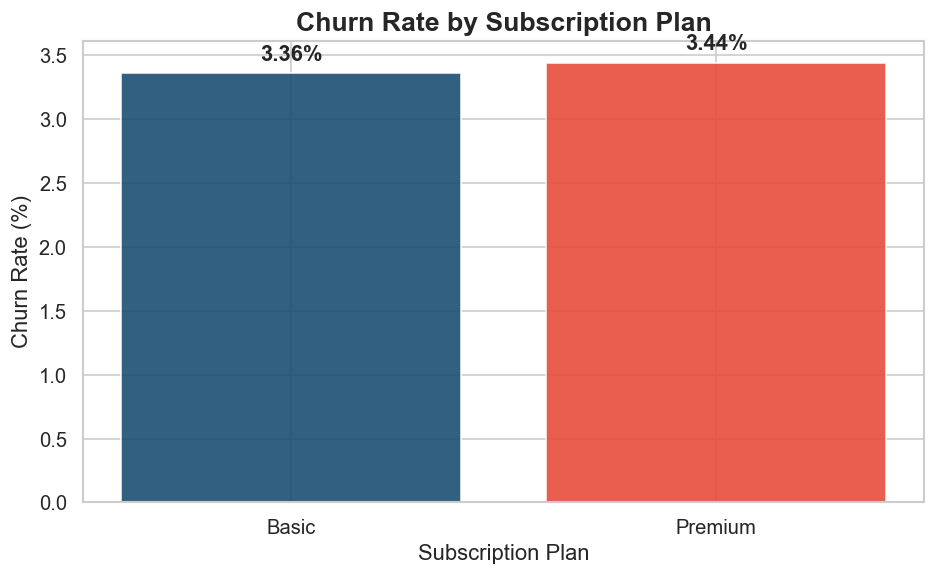

In [39]:
# Churn Rate by Subscription Plan

plan_churn = (
    df.groupby("subscription_plan")["churn_next_8_weeks"]
    .mean()
    .reset_index()
)

plan_churn["churn_rate_percent"] = (
    plan_churn["churn_next_8_weeks"] * 100
)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    plan_churn["subscription_plan"],
    plan_churn["churn_rate_percent"],
    color=[PALETTE[0], PALETTE[3]],
    edgecolor='white',
    alpha=0.9
)

# Value labels
for bar, value in zip(
    bars,
    plan_churn["churn_rate_percent"]
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{value:.2f}%",
        ha='center',
        fontweight='bold'
    )

ax.set_title(
    "Churn Rate by Subscription Plan",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("Subscription Plan")
ax.set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

##### Age Group vs Churn

This section examines how churn rates vary across different age groups within the dataset. Customer demographics may influence engagement patterns and retention behavior over time. Understanding these differences can help the business personalize interventions and improve customer retention strategies for specific user segments.

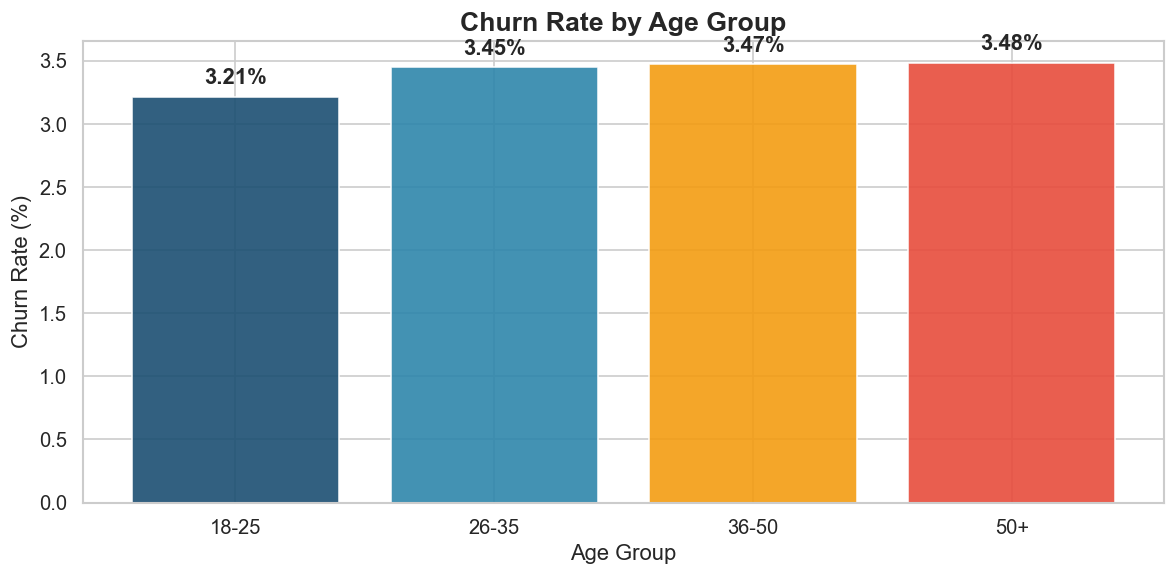

In [40]:
# Churn Rate by Age Group

age_churn = (
    df.groupby("age_group")["churn_next_8_weeks"]
    .mean()
    .reset_index()
)

age_churn["churn_rate_percent"] = (
    age_churn["churn_next_8_weeks"] * 100
)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    age_churn["age_group"],
    age_churn["churn_rate_percent"],
    color=PALETTE[:4],
    edgecolor='white',
    alpha=0.9
)

# Value labels
for bar, value in zip(
    bars,
    age_churn["churn_rate_percent"]
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{value:.2f}%",
        ha='center',
        fontweight='bold'
    )

ax.set_title(
    "Churn Rate by Age Group",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

##### Payment Failures Before Churn

This section analyzes payment failure trends for churners and retained users over time. Payment-related issues can be an important operational signal associated with customer churn. Identifying increasing payment failures before churn can help the company proactively resolve billing issues and reduce customer loss.

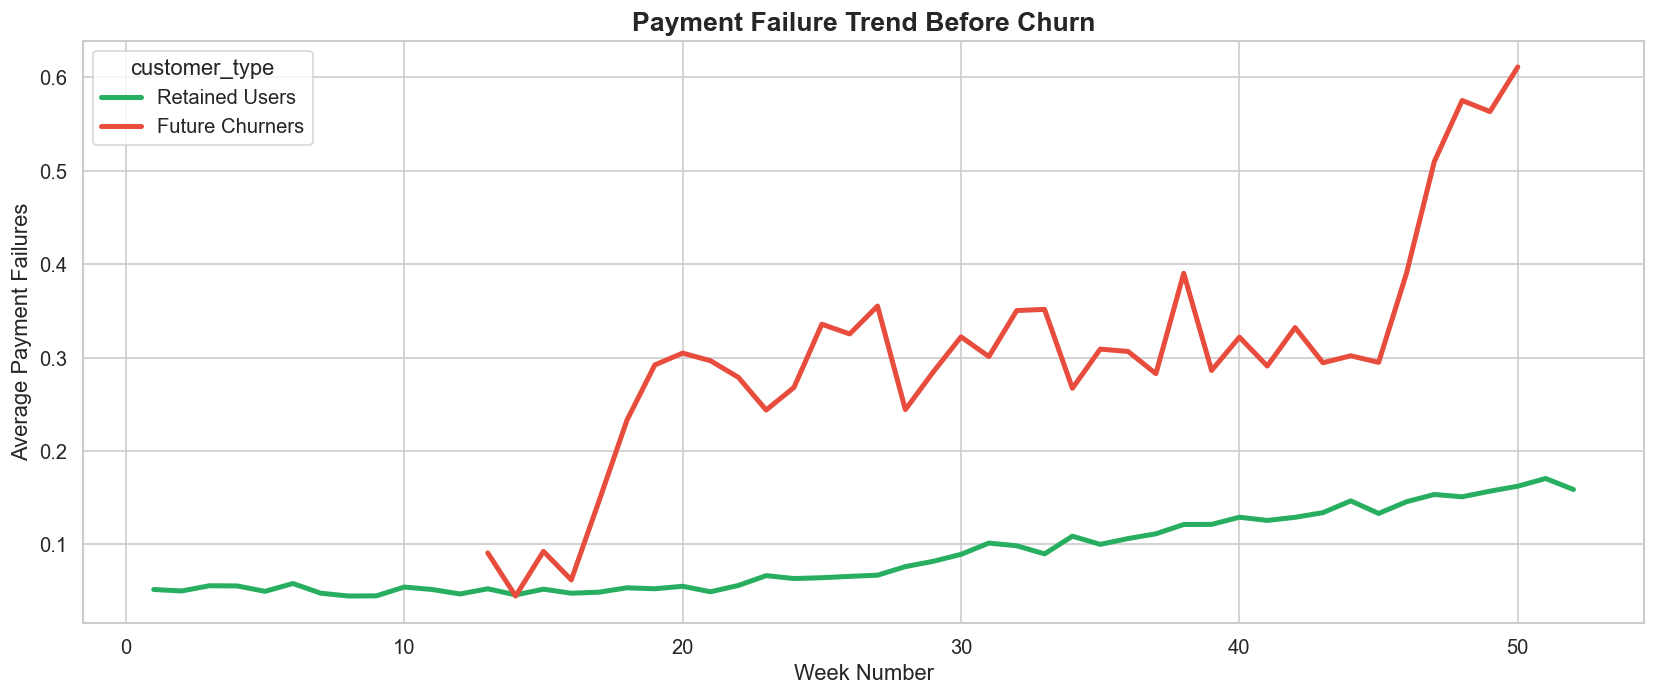

In [41]:
# Payment Failure Trend

payment_trend = (
    df.groupby(
        ["week_number", "churn_next_8_weeks"]
    )["payment_failures"]
    .mean()
    .reset_index()
)

payment_trend["customer_type"] = (
    payment_trend["churn_next_8_weeks"]
    .map({
        0: "Retained Users",
        1: "Future Churners"
    })
)

# Print values
# print(payment_trend.round(2))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=payment_trend,
    x="week_number",
    y="payment_failures",
    hue="customer_type",
    palette=[PALETTE[4], PALETTE[3]],
    linewidth=3,
    ax=ax
)

ax.set_title(
    "Payment Failure Trend Before Churn",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("Week Number")
ax.set_ylabel("Average Payment Failures")

plt.tight_layout()
plt.show()

##### Support Tickets Before Churn

This section studies customer support activity before churn occurs. Frequent support requests may indicate dissatisfaction, technical issues, or negative customer experiences. Understanding this behavior can help the business identify users who may require additional assistance before they churn.

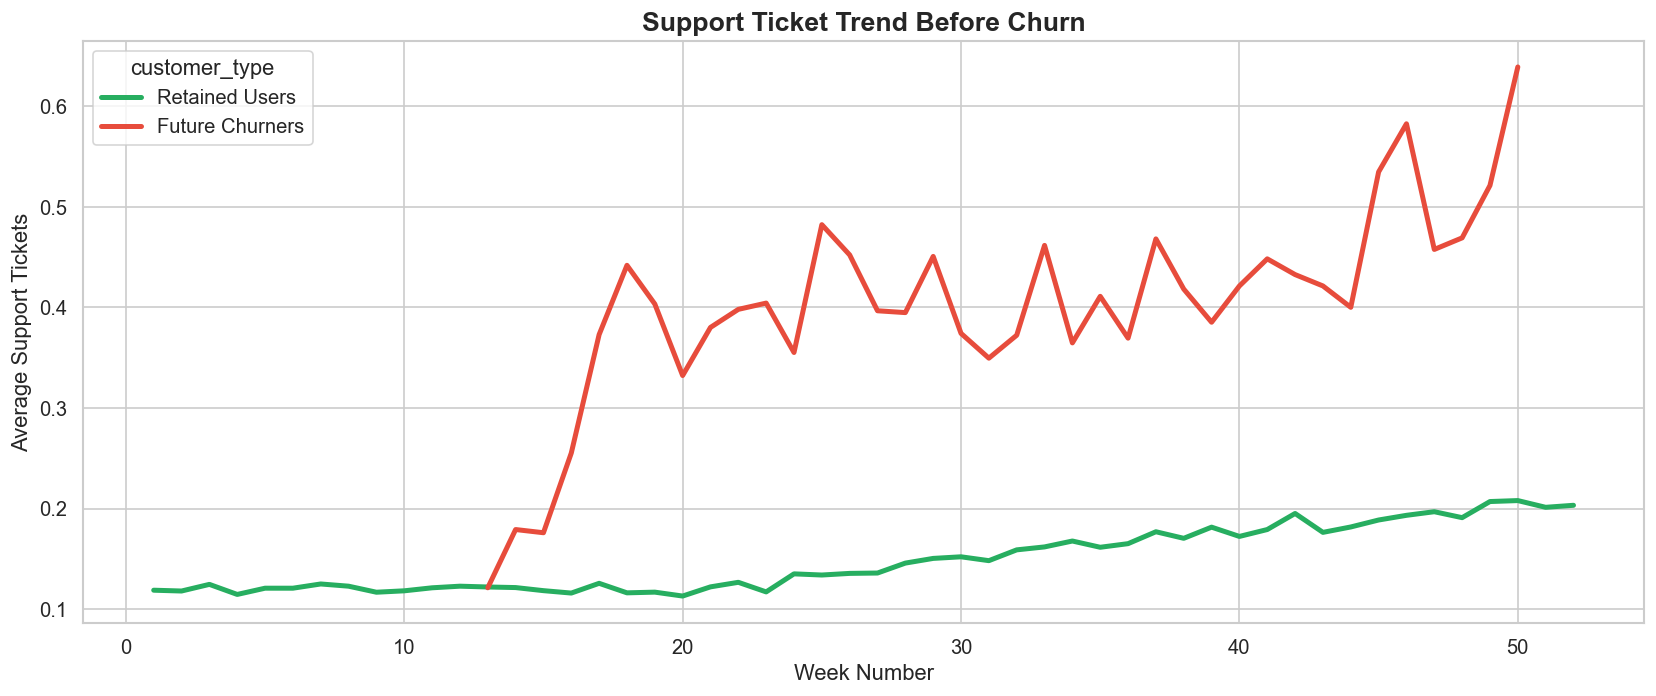

In [42]:
# Support Ticket Trend

support_trend = (
    df.groupby(
        ["week_number", "churn_next_8_weeks"]
    )["support_tickets"]
    .mean()
    .reset_index()
)

support_trend["customer_type"] = (
    support_trend["churn_next_8_weeks"]
    .map({
        0: "Retained Users",
        1: "Future Churners"
    })
)

# Print values
# print(support_trend.round(2))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=support_trend,
    x="week_number",
    y="support_tickets",
    hue="customer_type",
    palette=[PALETTE[4], PALETTE[3]],
    linewidth=3,
    ax=ax
)

ax.set_title(
    "Support Ticket Trend Before Churn",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("Week Number")
ax.set_ylabel("Average Support Tickets")

plt.tight_layout()
plt.show()

##### Correlation Heatmap

This section visualizes correlations between numerical features in the dataset. The heatmap helps identify relationships between user behavior metrics and the churn target variable. Understanding feature relationships supports feature selection, model interpretation, and detection of highly correlated variables.

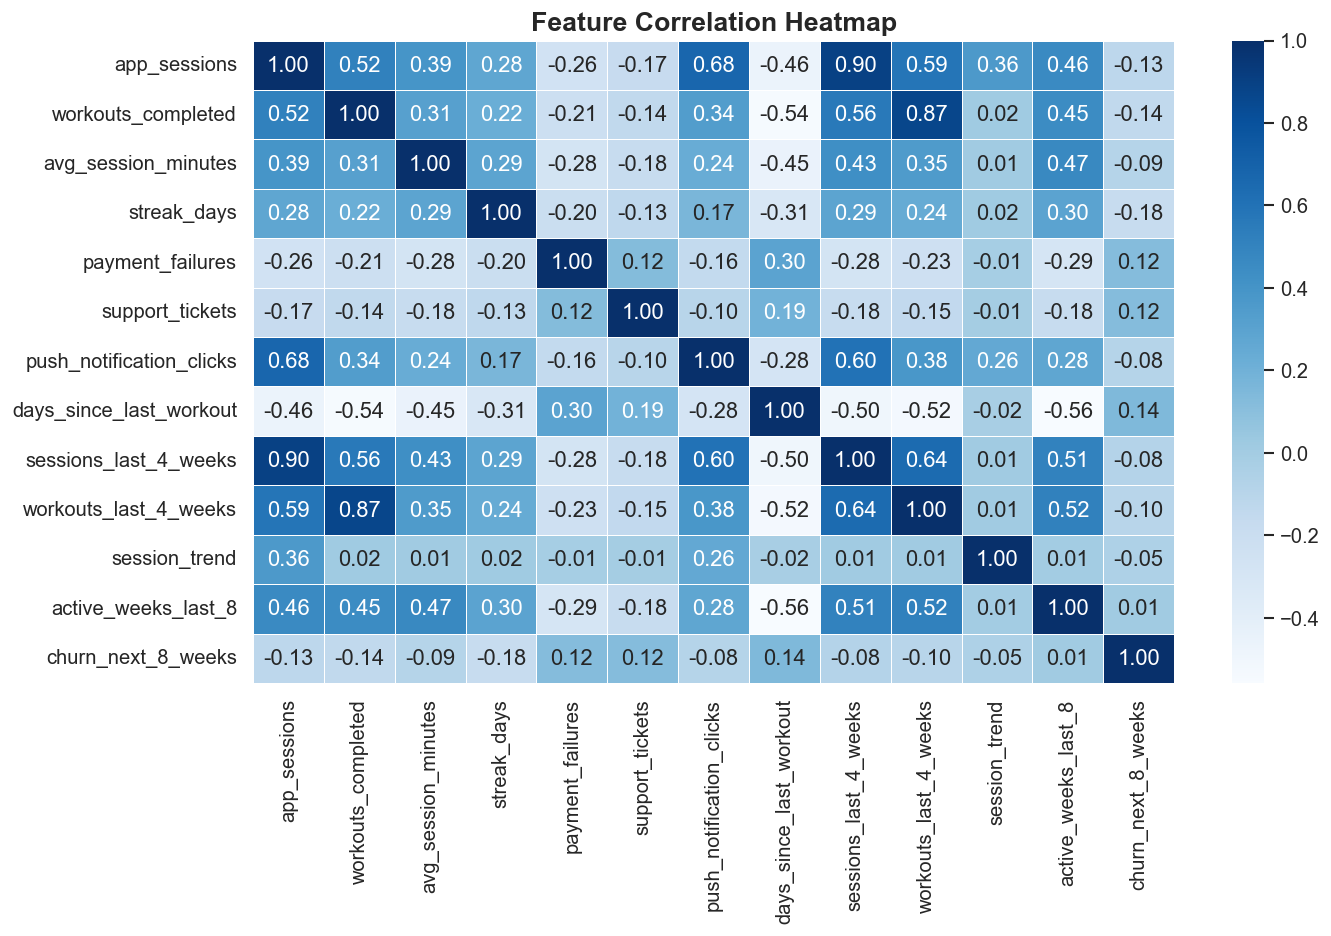

In [43]:
# Correlation Heatmap

numerical_cols = [
    "app_sessions",
    "workouts_completed",
    "avg_session_minutes",
    "streak_days",
    "payment_failures",
    "support_tickets",
    "push_notification_clicks",
    "days_since_last_workout",
    "sessions_last_4_weeks",
    "workouts_last_4_weeks",
    "session_trend",
    "active_weeks_last_8",
    "churn_next_8_weeks"
]

corr_matrix = (
    df[numerical_cols]
    .corr()
)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    "Feature Correlation Heatmap",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

##### Data Preprocessing

This section prepares the dataset for machine learning by handling missing values, encoding categorical variables, and creating additional temporal features. Proper preprocessing is necessary because machine learning algorithms require clean numerical input data. This step also ensures that the dataset is ready for time-based modeling and evaluation.

In [44]:
# Copy dataset
model_df = df.copy()

In [45]:
# Handle missing values
print("Missing Values Before Imputation:")
print(model_df.isnull().sum())

Missing Values Before Imputation:
user_id                        0
week_date                      0
week_number                    0
subscription_plan              0
age_group                      0
app_sessions                   0
workouts_completed             0
avg_session_minutes         5134
streak_days                    0
payment_failures               0
support_tickets                0
push_notification_clicks       0
days_since_last_workout        0
churn_next_8_weeks             0
sessions_last_4_weeks          0
workouts_last_4_weeks          0
session_trend                  0
active_weeks_last_8            0
dtype: int64


In [46]:
# Fill missing session minutes using median
median_session = model_df["avg_session_minutes"].median()

model_df["avg_session_minutes"] = (
    model_df["avg_session_minutes"]
    .fillna(median_session)
)

print("\nMissing Values After Imputation:")
print(model_df.isnull().sum())


Missing Values After Imputation:
user_id                     0
week_date                   0
week_number                 0
subscription_plan           0
age_group                   0
app_sessions                0
workouts_completed          0
avg_session_minutes         0
streak_days                 0
payment_failures            0
support_tickets             0
push_notification_clicks    0
days_since_last_workout     0
churn_next_8_weeks          0
sessions_last_4_weeks       0
workouts_last_4_weeks       0
session_trend               0
active_weeks_last_8         0
dtype: int64


In [47]:
# Encode categorical variables
categorical_cols = [
    "subscription_plan",
    "age_group"
]

encoders = {}

for col in categorical_cols:
    
    le = LabelEncoder()
    
    model_df[col] = le.fit_transform(
        model_df[col]
    )
    
    encoders[col] = le

print("\nEncoded Columns:")
print(model_df[categorical_cols].head())


Encoded Columns:
   subscription_plan  age_group
0                  0          1
1                  0          1
2                  0          1
3                  0          1
4                  0          1


In [48]:
# Create Additional Temporal Features

# Month
model_df["month"] = (
    model_df["week_date"]
    .dt.month
)

# Quarter
model_df["quarter"] = (
    model_df["week_date"]
    .dt.quarter
)

# Week of Year
model_df["week_of_year"] = (
    model_df["week_date"]
    .dt.isocalendar()
    .week
)

print("\nTemporal Features Added:")
print(
    model_df[
        ["week_date", "month", "quarter", "week_of_year"]
    ].head()
)


Temporal Features Added:
   week_date  month  quarter  week_of_year
0 2025-01-06      1        1             2
1 2025-01-13      1        1             3
2 2025-01-20      1        1             4
3 2025-01-27      1        1             5
4 2025-02-03      2        1             6


##### Feature Selection

This section defines the final feature set used for churn prediction modeling. The selected features include engagement metrics, behavioral trends, recency variables, and temporal indicators. Choosing relevant features is important because they directly influence model performance and the quality of churn predictions.

In [49]:
# Feature selection

feature_cols = [

    "week_number",
    "subscription_plan",
    "age_group",

    "app_sessions",
    "workouts_completed",
    "avg_session_minutes",
    "streak_days",

    "payment_failures",
    "support_tickets",
    "push_notification_clicks",

    "days_since_last_workout",

    "sessions_last_4_weeks",
    "workouts_last_4_weeks",

    "session_trend",
    "active_weeks_last_8",

    "month",
    "quarter",
    "week_of_year"
]

# Target column
target_col = "churn_next_8_weeks"

# Split features and target
X = model_df[feature_cols]
y = model_df[target_col]

print("Feature Matrix Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

Feature Matrix Shape:
(260000, 18)

Target Shape:
(260000,)


##### Temporal Train-Test Split

This section creates a time-based train-test split using chronological ordering instead of a random split. Temporal validation is important because it simulates real-world deployment conditions where future churn must be predicted using only past information. This approach also helps prevent data leakage and unrealistic model evaluation.

In [50]:
# Sort by date
model_df = model_df.sort_values(
    by="week_date"
)

# Create split date using 80th percentile
split_date = (
    model_df["week_date"]
    .quantile(0.80)
)

# Split data without overlap
train_df = model_df[
    model_df["week_date"] < split_date
]

test_df = model_df[
    model_df["week_date"] >= split_date
]

# Features
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

# Target
y_train = train_df[target_col]
y_test = test_df[target_col]

print("Training Set Shape:")
print(X_train.shape)

print("\nTesting Set Shape:")
print(X_test.shape)

print("\nTraining Date Range:")
print(train_df["week_date"].min())
print(train_df["week_date"].max())

print("\nTesting Date Range:")
print(test_df["week_date"].min())
print(test_df["week_date"].max())

Training Set Shape:
(205000, 18)

Testing Set Shape:
(55000, 18)

Training Date Range:
2025-01-06 00:00:00
2025-10-13 00:00:00

Testing Date Range:
2025-10-20 00:00:00
2025-12-29 00:00:00


##### Feature Scaling

This section standardizes numerical feature values using `StandardScaler`. Scaling ensures that features with different ranges contribute more consistently during model training. This preprocessing step is especially important for algorithms such as Logistic Regression that are sensitive to feature magnitudes.

In [51]:
# Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed.")

Scaling Completed.


##### Handle Class Imbalance

This section applies `SMOTE (Synthetic Minority Oversampling Technique)` to balance the churn and non-churn classes in the training data. Since churn prediction datasets are highly imbalanced, models may otherwise become biased toward predicting retained users. Balancing the dataset helps improve the model’s ability to correctly identify future churners.

In [52]:
# Apply SMOTE

smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = (
    smote.fit_resample(
        X_train_scaled,
        y_train
    )
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Before SMOTE:
churn_next_8_weeks
0    197808
1      7192
Name: count, dtype: int64

After SMOTE:
churn_next_8_weeks
0    197808
1    197808
Name: count, dtype: int64


##### Time Series Cross-Validation

This section evaluates the model using `TimeSeriesSplit` cross-validation, which preserves the temporal order of observations. Unlike random cross-validation, this method better reflects real-world deployment scenarios where future data should never influence past predictions. This step helps measure the stability and reliability of model performance over time.

In [53]:
# Time series cross-validation

tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Cross-validation scores
cv_scores = cross_val_score(
    xgb_cv_model,
    X_train_scaled,
    y_train,
    cv=tscv,
    scoring='roc_auc'
)

print("TimeSeriesSplit ROC-AUC Scores:")
print(cv_scores)

print("\nMean ROC-AUC:")
print(round(cv_scores.mean(), 4))

TimeSeriesSplit ROC-AUC Scores:
[0.5        0.61715711 0.85959647 0.8631853  0.87613334]

Mean ROC-AUC:
0.7432


##### Logistic Regression

This section trains and evaluates a Logistic Regression model as a baseline classification approach for churn prediction. Logistic Regression is interpretable and provides a useful benchmark for comparing more advanced machine learning models. The evaluation metrics help assess how well the model identifies future churners.

In [54]:
# Logistic Regression model

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
lr_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

y_prob_lr = lr_model.predict_proba(
    X_test_scaled
)[:, 1]

# Evaluation metrics
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

# Results
print("Logistic Regression Results")
print("-" * 40)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

Logistic Regression Results
----------------------------------------
Accuracy : 0.4426
Precision: 0.0473
Recall   : 0.9440
F1-Score : 0.0901
ROC-AUC  : 0.9009

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.43      0.60     53392
           1       0.05      0.94      0.09      1608

    accuracy                           0.44     55000
   macro avg       0.52      0.69      0.34     55000
weighted avg       0.97      0.44      0.58     55000



##### Decision Tree

This section trains and evaluates a Decision Tree model for temporal churn prediction. Decision Trees can capture non-linear relationships and interaction effects between features. This model also provides better interpretability than many ensemble approaches while offering improved predictive capability compared to simple linear models.

In [55]:
# Decision Tree model

dt_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

# Train model
dt_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Predictions
y_pred_dt = dt_model.predict(X_test_scaled)

y_prob_dt = dt_model.predict_proba(
    X_test_scaled
)[:, 1]

# Evaluation metrics
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt
)

dt_recall = recall_score(
    y_test,
    y_pred_dt
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt
)

dt_auc = roc_auc_score(
    y_test,
    y_prob_dt
)

# Results
print("Decision Tree Results")
print("-" * 40)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-Score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

Decision Tree Results
----------------------------------------
Accuracy : 0.9405
Precision: 0.3000
Recall   : 0.7767
F1-Score : 0.4328
ROC-AUC  : 0.8748

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     53392
           1       0.30      0.78      0.43      1608

    accuracy                           0.94     55000
   macro avg       0.65      0.86      0.70     55000
weighted avg       0.97      0.94      0.95     55000



##### Random Forest

This section trains and evaluates a Random Forest model using multiple decision trees. Random Forest improves predictive performance by reducing overfitting and increasing model stability through ensemble learning. The model helps capture complex behavioral patterns associated with churn across temporal user activity data.

In [56]:
# Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

y_prob_rf = rf_model.predict_proba(
    X_test_scaled
)[:, 1]

# Evaluation metrics
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

# Results
print("Random Forest Results")
print("-" * 40)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Random Forest Results
----------------------------------------
Accuracy : 0.9372
Precision: 0.2930
Recall   : 0.8122
F1-Score : 0.4307
ROC-AUC  : 0.9227

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.97     53392
           1       0.29      0.81      0.43      1608

    accuracy                           0.94     55000
   macro avg       0.64      0.88      0.70     55000
weighted avg       0.97      0.94      0.95     55000



##### XGBoost

This section trains and evaluates an XGBoost model, which is an advanced gradient boosting algorithm commonly used for high-performance predictive modeling. XGBoost is well suited for churn prediction because it can handle complex feature interactions and imbalanced datasets effectively.

In [57]:
# XGBoost model

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train model
xgb_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

y_prob_xgb = xgb_model.predict_proba(
    X_test_scaled
)[:, 1]

# Evaluation metrics
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)

xgb_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

# Results
print("XGBoost Results")
print("-" * 40)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

XGBoost Results
----------------------------------------
Accuracy : 0.9757
Precision: 0.5649
Recall   : 0.7332
F1-Score : 0.6382
ROC-AUC  : 0.9349

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     53392
           1       0.56      0.73      0.64      1608

    accuracy                           0.98     55000
   macro avg       0.78      0.86      0.81     55000
weighted avg       0.98      0.98      0.98     55000



##### Model Comparison

This section compares all trained machine learning models using evaluation metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [58]:
# Model comparison table

model_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall,
        xgb_recall
    ],

    "F1-Score": [
        lr_f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ],

    "ROC-AUC": [
        lr_auc,
        dt_auc,
        rf_auc,
        xgb_auc
    ]
})

print(
    model_results.round(4)
)

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.4426     0.0473  0.9440    0.0901   0.9009
1        Decision Tree    0.9405     0.3000  0.7767    0.4328   0.8748
2        Random Forest    0.9372     0.2930  0.8122    0.4307   0.9227
3              XGBoost    0.9757     0.5649  0.7332    0.6382   0.9349


##### Threshold Optimization

This section evaluates different probability thresholds for the XGBoost model to identify the threshold that produces the best balance between Precision and Recall. Instead of relying only on the default 0.5 cutoff, threshold optimization helps align the model with business objectives and improves classification performance for imbalanced churn prediction tasks.

In [59]:
# Threshold optimization

thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    temp_pred = (
        y_prob_xgb >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            temp_pred
        ),

        "Recall": recall_score(
            y_test,
            temp_pred
        ),

        "F1": f1_score(
            y_test,
            temp_pred
        )
    })

# Results table
threshold_df = pd.DataFrame(
    threshold_results
)

# Best threshold
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax(),
    "Threshold"
]

print("Best Threshold:")
print(best_threshold)

print("\nThreshold Optimization Results:")
print(threshold_df.round(4))

Best Threshold:
0.6000000000000002

Threshold Optimization Results:
    Threshold  Precision  Recall      F1
0        0.10     0.1371  0.8750  0.2370
1        0.15     0.2509  0.8396  0.3864
2        0.20     0.3272  0.8234  0.4683
3        0.25     0.3799  0.8029  0.5158
4        0.30     0.4240  0.7892  0.5516
5        0.35     0.4624  0.7774  0.5799
6        0.40     0.4986  0.7600  0.6021
7        0.45     0.5317  0.7463  0.6210
8        0.50     0.5649  0.7332  0.6382
9        0.55     0.5966  0.7146  0.6503
10       0.60     0.6309  0.6940  0.6609
11       0.65     0.6587  0.6517  0.6552
12       0.70     0.6924  0.6188  0.6535
13       0.75     0.7241  0.5647  0.6345
14       0.80     0.7604  0.4894  0.5955
15       0.85     0.8138  0.3669  0.5058
16       0.90     0.8560  0.1996  0.3238


##### Accuracy Comparison

This section visualizes and compares model accuracy scores across all machine learning models.

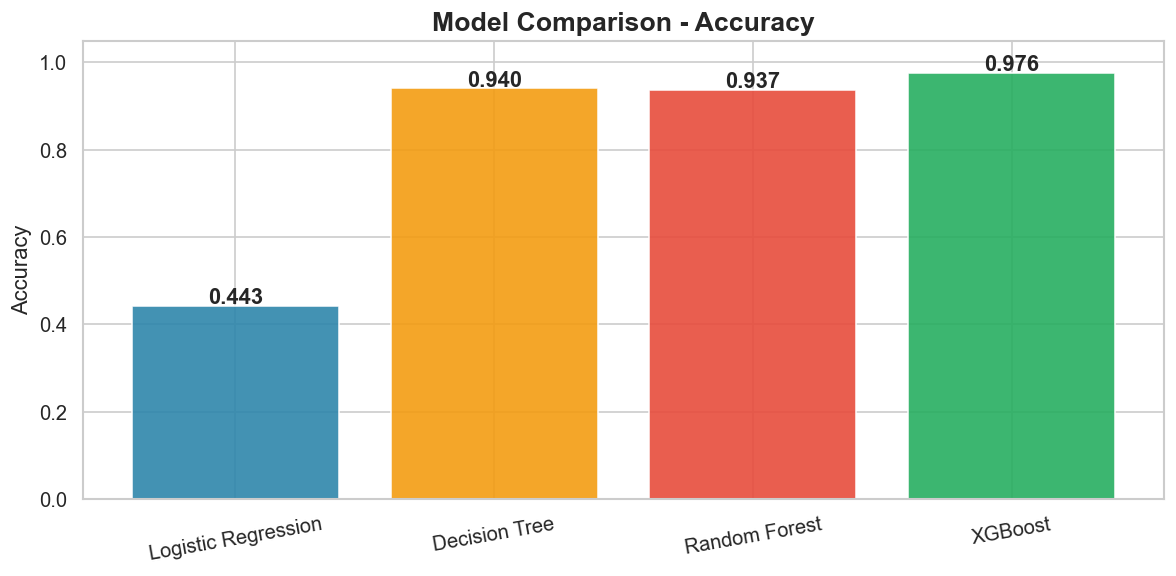

In [60]:
# Accuracy comparison plot

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    model_results["Model"],
    model_results["Accuracy"],
    color=PALETTE[1:5],
    edgecolor='white',
    alpha=0.9
)

# Add value labels
for bar, value in zip(
    bars,
    model_results["Accuracy"]
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{value:.3f}",
        ha='center',
        fontweight='bold'
    )

ax.set_title(
    "Model Comparison - Accuracy",
    fontsize=16,
    fontweight='bold'
)

ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

##### Confusion Matrices

This section visualizes confusion matrices for all trained models to analyze prediction outcomes in detail.

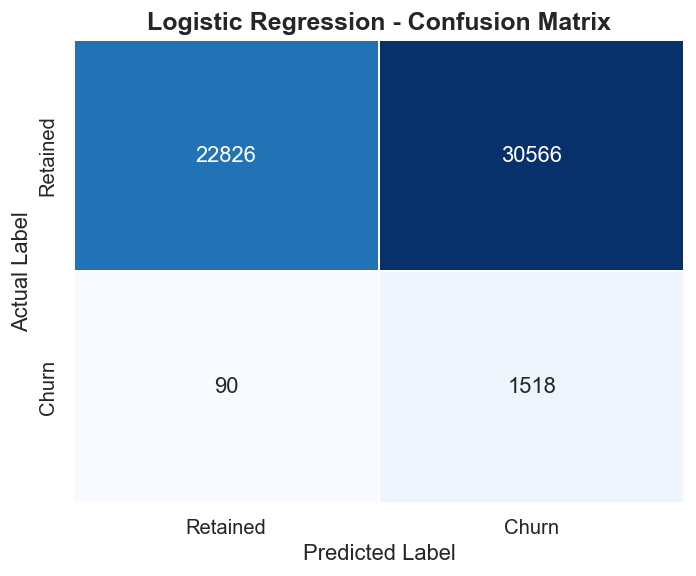

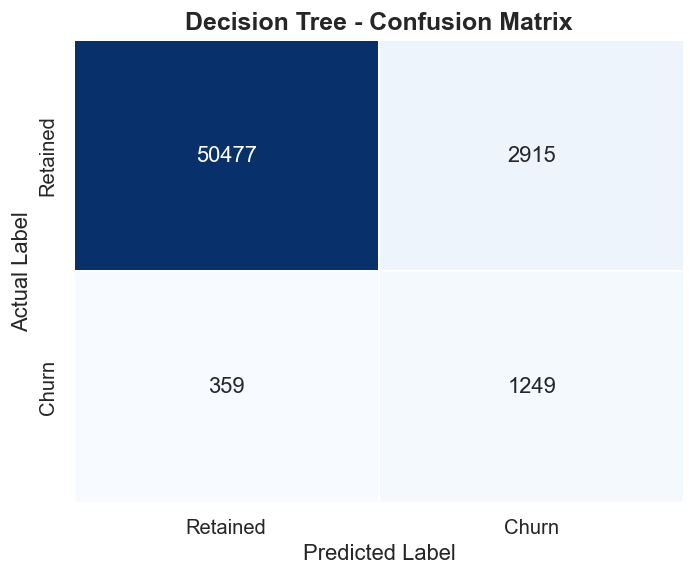

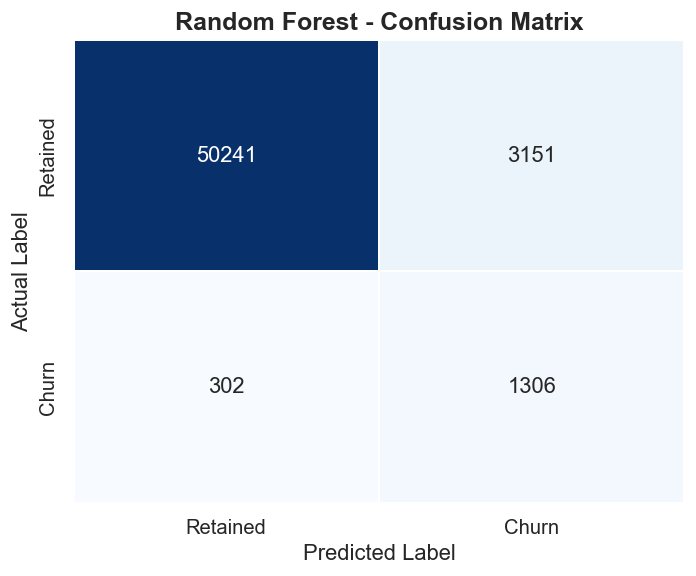

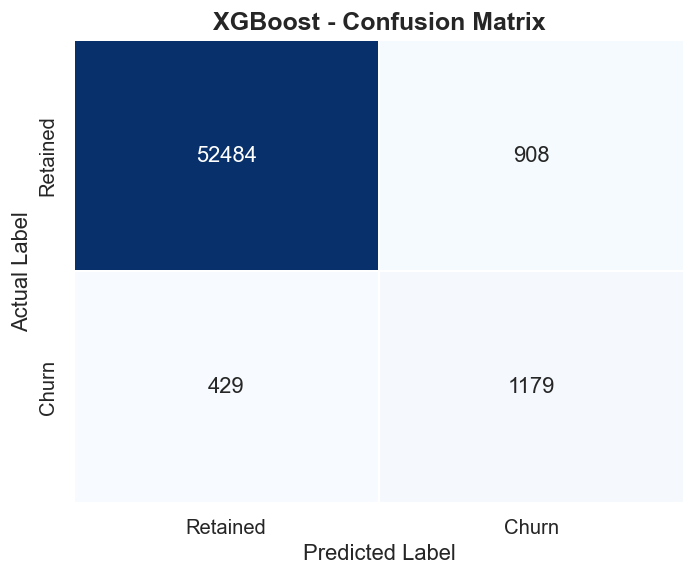

In [61]:
# Confusion matrices

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for model_name, predictions in models.items():

    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        predictions
    )

    # Plot
    fig, ax = plt.subplots(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        linewidths=1,
        linecolor='white',
        ax=ax
    )

    ax.set_title(
        f"{model_name} - Confusion Matrix",
        fontsize=15,
        fontweight='bold'
    )

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

    ax.set_xticklabels([
        "Retained",
        "Churn"
    ])

    ax.set_yticklabels([
        "Retained",
        "Churn"
    ])

    plt.tight_layout()
    plt.show()

##### F1-Score Comparison

This section compares the F1-Scores of all machine learning models.

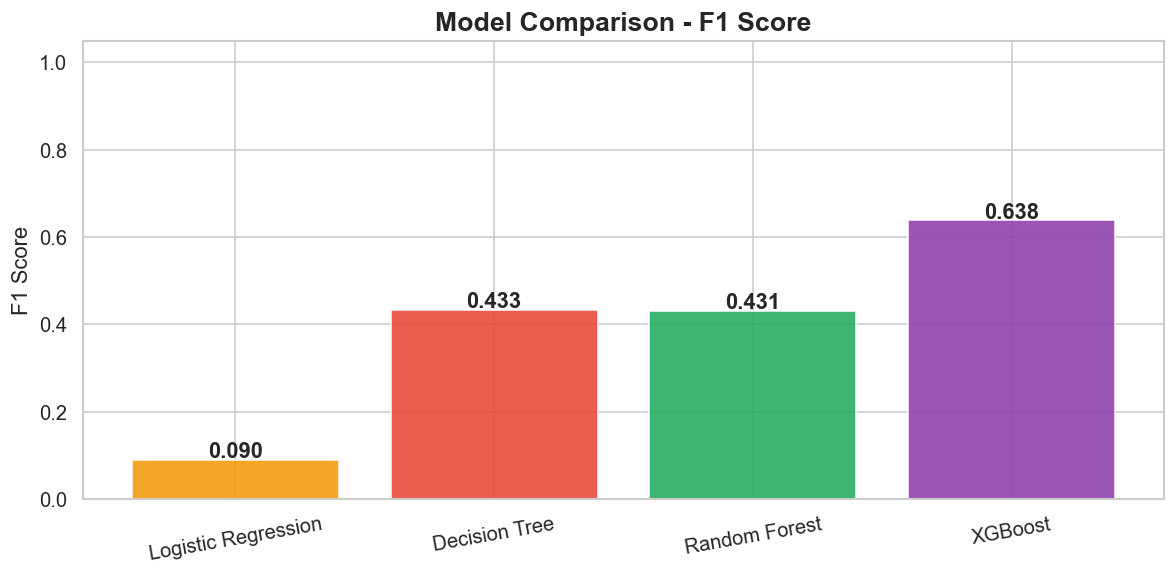

In [62]:
# F1-score comparison plot

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    model_results["Model"],
    model_results["F1-Score"],
    color=PALETTE[2:6],
    edgecolor='white',
    alpha=0.9
)

# Add value labels
for bar, value in zip(
    bars,
    model_results["F1-Score"]
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{value:.3f}",
        ha='center',
        fontweight='bold'
    )

ax.set_title(
    "Model Comparison - F1 Score",
    fontsize=16,
    fontweight='bold'
)

ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

##### ROC Curve Comparison

This section visualizes ROC curves for all machine learning models and compares their ROC-AUC scores.

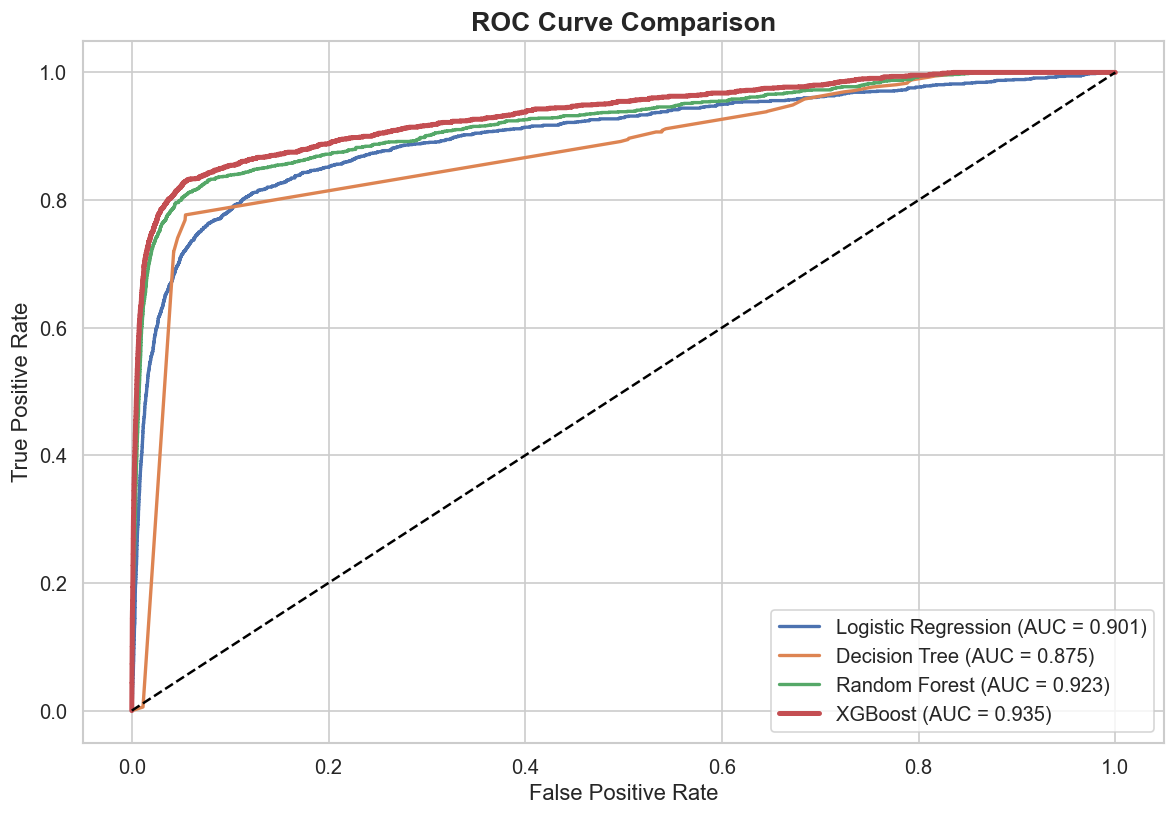

In [63]:
# ROC curve values
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    y_prob_dt
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})",
    linewidth=2
)

ax.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {dt_auc:.3f})",
    linewidth=2
)

ax.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})",
    linewidth=2
)

ax.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {xgb_auc:.3f})",
    linewidth=3
)

# Random baseline
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='black'
)

ax.set_title(
    "ROC Curve Comparison",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.legend()

plt.tight_layout()
plt.show()

##### Precision-Recall Curve

This section evaluates the Precision-Recall relationship for the XGBoost model.

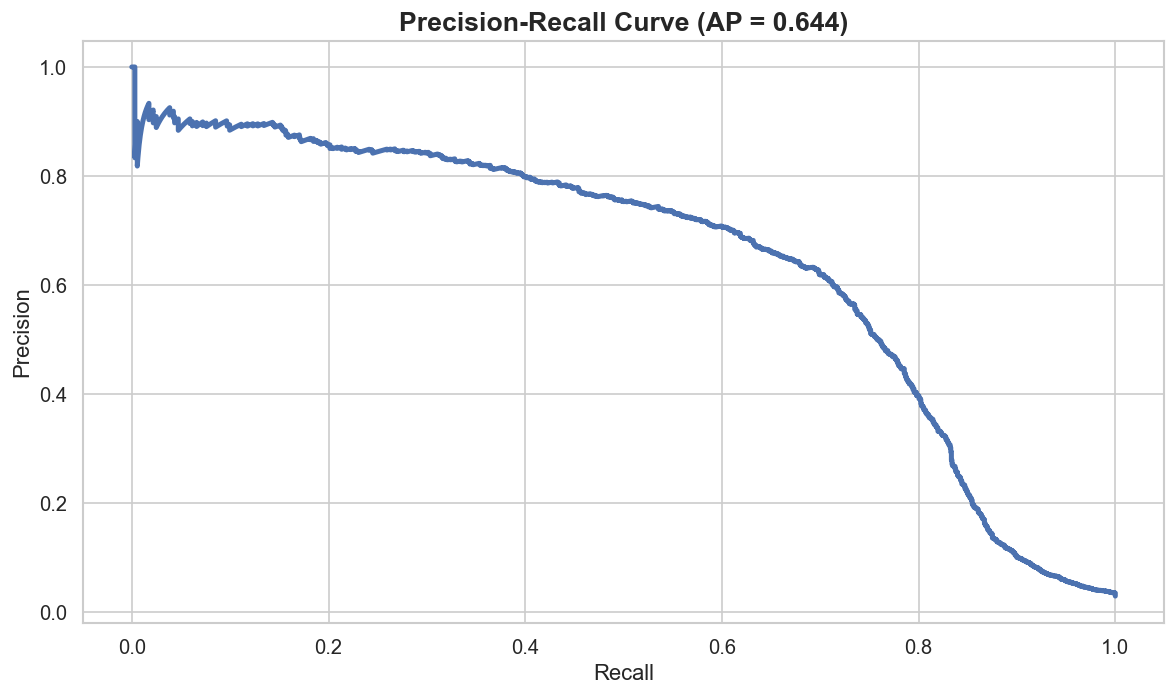

In [64]:
# Precision-recall values

precision_vals, recall_vals, _ = precision_recall_curve(
    y_test,
    y_prob_xgb
)

# Average precision score
avg_precision = average_precision_score(
    y_test,
    y_prob_xgb
)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    recall_vals,
    precision_vals,
    linewidth=3
)

ax.set_title(
    f"Precision-Recall Curve (AP = {avg_precision:.3f})",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

plt.tight_layout()
plt.show()

##### Calibration Curve

This section evaluates how well the predicted churn probabilities align with actual observed churn outcomes.

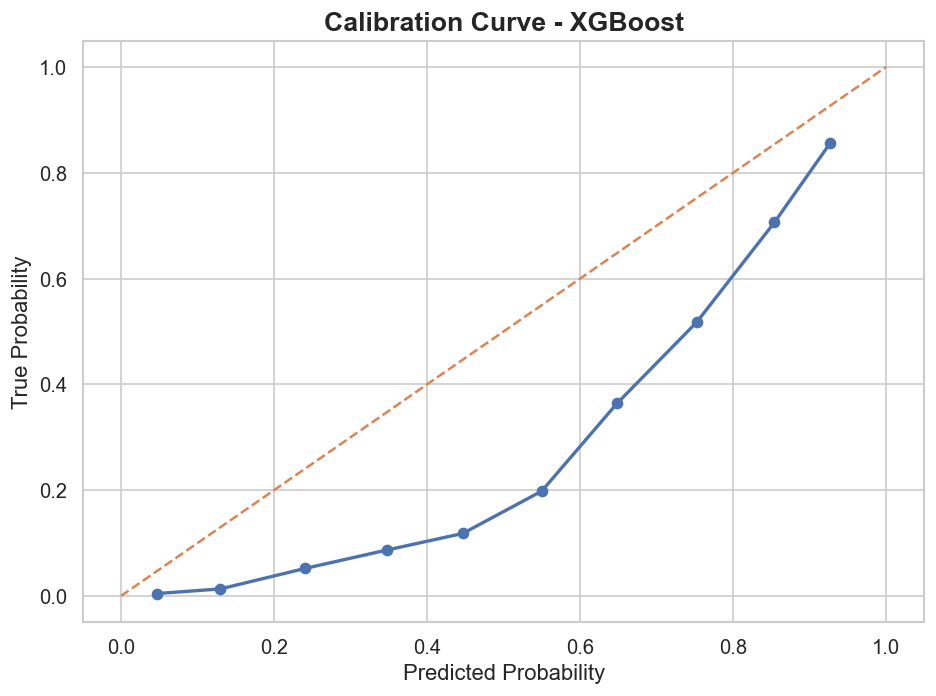

In [65]:
# Calibration values

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob_xgb,
    n_bins=10
)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    prob_pred,
    prob_true,
    marker='o',
    linewidth=2
)

# Perfect calibration line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

ax.set_title(
    "Calibration Curve - XGBoost",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("Predicted Probability")
ax.set_ylabel("True Probability")

plt.tight_layout()
plt.show()

In [73]:
# Calibration table
calibration_df = pd.DataFrame({
    "predicted_probability": prob_pred,
    "true_probability": prob_true
})

# Calibration gap
calibration_df["gap"] = (
    calibration_df["predicted_probability"]
    - calibration_df["true_probability"]
)

print(calibration_df.round(3))

   predicted_probability  true_probability    gap
0                  0.047             0.004  0.042
1                  0.130             0.013  0.117
2                  0.241             0.052  0.189
3                  0.347             0.087  0.260
4                  0.447             0.118  0.328
5                  0.550             0.198  0.352
6                  0.648             0.364  0.284
7                  0.752             0.517  0.235
8                  0.854             0.706  0.148
9                  0.927             0.856  0.071


In [74]:
brier = brier_score_loss(
    y_test,
    y_prob_xgb
)

print("Brier Score:", round(brier, 4))

Brier Score: 0.0225


##### XGBoost Feature Importance

This section analyzes feature importance scores generated by the XGBoost model. The goal is to identify which behavioral and temporal variables contribute most strongly to churn prediction. Understanding feature importance helps improve business interpretation and supports actionable retention strategies.

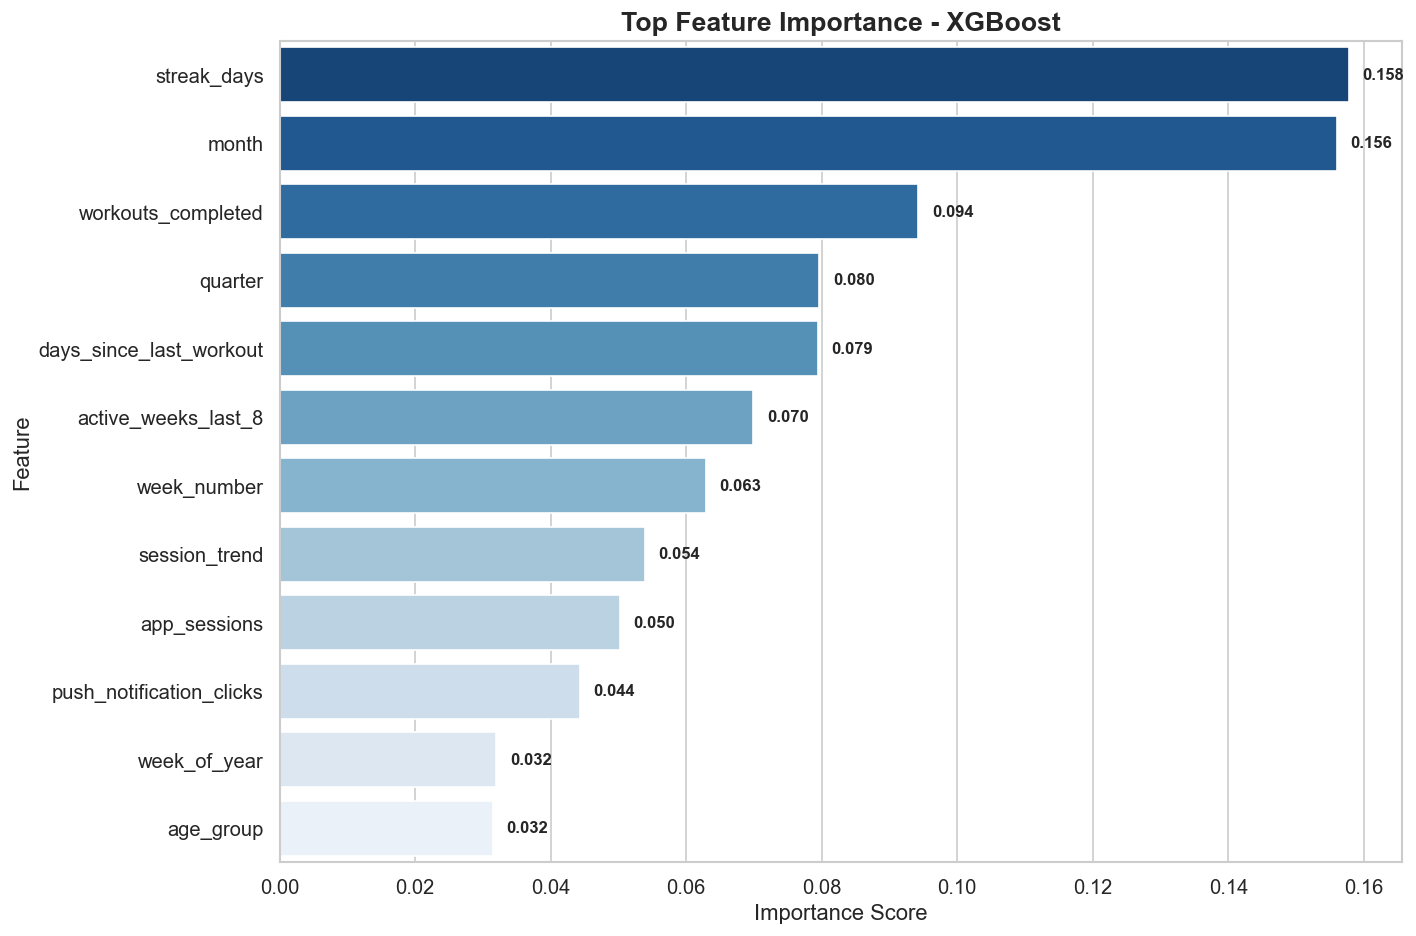

                     Feature  Importance
0                streak_days    0.157798
1                      month    0.156053
2         workouts_completed    0.094260
3                    quarter    0.079655
4    days_since_last_workout    0.079463
5        active_weeks_last_8    0.069891
6                week_number    0.062932
7              session_trend    0.053916
8               app_sessions    0.050234
9   push_notification_clicks    0.044269
10              week_of_year    0.031985
11                 age_group    0.031513


In [66]:
# Feature importance

importance_df = pd.DataFrame({

    "Feature": feature_cols,
    "Importance": xgb_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

top_features = importance_df.head(12)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="Blues_r",
    dodge=False,
    legend=False,
    ax=ax
)

# Add values at end of bars
for index, value in enumerate(importance_df.head(12)["Importance"]):
    ax.text(
        value + 0.002,          
        index,
        f"{value:.3f}",
        va='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    "Top Feature Importance - XGBoost",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("Importance Score")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

# Display importance table
print(top_features)

##### SHAP Explainability

This section visualizes the distribution of predicted churn probabilities for retained users and future churners. The goal is to evaluate how clearly the model separates high-risk customers from low-risk customers. Strong separation between the two groups indicates good predictive performance.

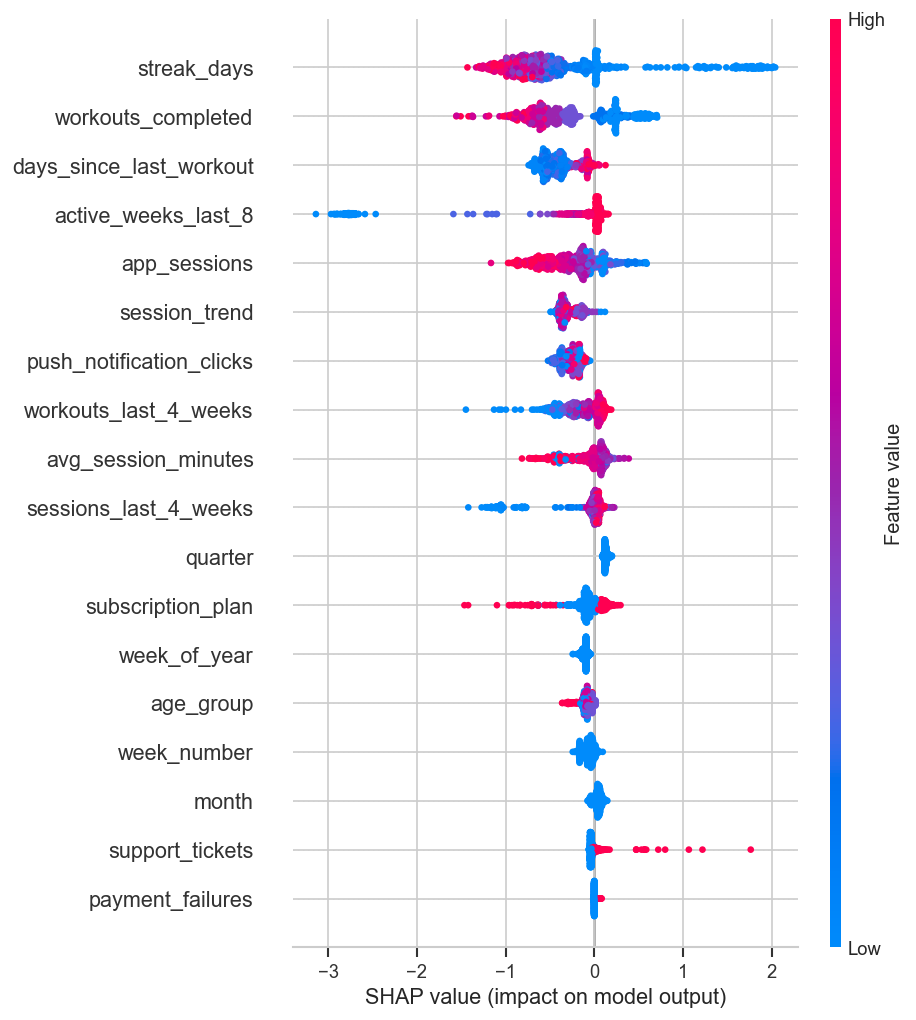

In [67]:
# SHAP explainer

explainer = shap.TreeExplainer(
    xgb_model
)

# Sample test data
sample_data = X_test_scaled[:1000]

# SHAP values
shap_values = explainer.shap_values(
    sample_data
)

# Summary plot
shap.summary_plot(
    shap_values,
    sample_data,
    feature_names=feature_cols
)

In [68]:
# SHAP dataframe
shap_df = pd.DataFrame(
    shap_values,
    columns=feature_cols
)

# Mean absolute SHAP importance
mean_shap = (
    shap_df.abs()
    .mean()
    .sort_values(ascending=False)
)

print(mean_shap)

# Min/max SHAP ranges
shap_ranges = pd.DataFrame({
    "feature": feature_cols,
    "min_shap": shap_df.min().values,
    "max_shap": shap_df.max().values,
    "range": shap_df.max().values - shap_df.min().values
}).sort_values(
    by="range",
    ascending=False
)

print(shap_ranges)

streak_days                 0.688856
workouts_completed          0.477233
days_since_last_workout     0.412688
active_weeks_last_8         0.368332
app_sessions                0.306247
session_trend               0.291798
push_notification_clicks    0.264479
workouts_last_4_weeks       0.194161
avg_session_minutes         0.159306
sessions_last_4_weeks       0.143943
quarter                     0.127528
subscription_plan           0.119215
week_of_year                0.105292
age_group                   0.088104
week_number                 0.064587
month                       0.047941
support_tickets             0.046071
payment_failures            0.003582
dtype: float32
                     feature  min_shap  max_shap     range
6                streak_days -1.429730  2.037999  3.467729
14       active_weeks_last_8 -3.137098  0.160572  3.297670
4         workouts_completed -1.554861  0.707813  2.262674
8            support_tickets -0.061866  1.762408  1.824274
1          subscription_

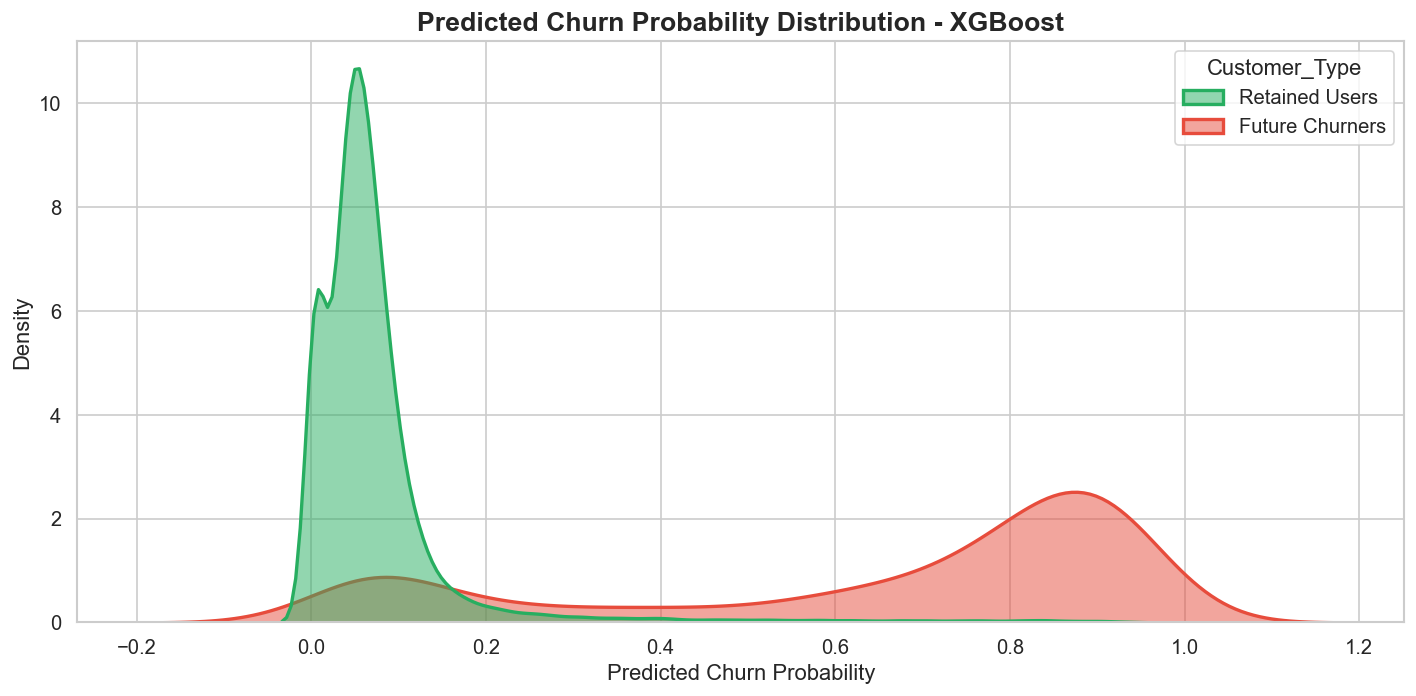

In [69]:
# XGBoost Predicted Churn Probability Distribution

prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted_Probability": y_prob_xgb
})

prediction_df["Customer_Type"] = (
    prediction_df["Actual"]
    .map({
        0: "Retained Users",
        1: "Future Churners"
    })
)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(
    data=prediction_df,
    x="Predicted_Probability",
    hue="Customer_Type",
    fill=True,
    common_norm=False,
    palette=[PALETTE[4], PALETTE[3]],
    alpha=0.5,
    linewidth=2,
    ax=ax
)

ax.set_title(
    "Predicted Churn Probability Distribution - XGBoost",
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel("Predicted Churn Probability")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

##### High-Risk Customer Segmentation

This section segments customers into low-risk, medium-risk, and high-risk groups based on predicted churn probabilities. This segmentation can help the business prioritize targeted retention campaigns and customer interventions.

In [70]:
# High-Risk Customer Segmentation

test_results = test_df.copy()

test_results["predicted_churn_probability"] = y_prob_xgb

# Risk buckets
test_results["risk_segment"] = pd.cut(
    test_results["predicted_churn_probability"],
    bins=[0, 0.3, 0.7, 1.0],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

# Segment summary
risk_summary = (
    test_results.groupby(
        "risk_segment",
        observed=True
    )[
        [
            "app_sessions",
            "workouts_completed",
            "days_since_last_workout",
            "streak_days"
        ]
    ]
    .mean()
    .round(2)
)

risk_summary.index.name = None

# Styled table
styled_risk_summary = (
    risk_summary.style
    .format("{:.2f}")
    .set_caption("Customer Risk Segment Summary")
)


styled_risk_summary

,app_sessions,workouts_completed,days_since_last_workout,streak_days
Low Risk,7.49,2.54,6.74,12.71
Medium Risk,5.52,1.39,9.81,0.80
High Risk,3.62,0.41,15.12,0.03


##### Business KPI and Cost-Based Evaluation

The churn prediction system was developed to support customer retention decisions for FitPulse. While evaluation metrics such as ROC-AUC and F1-score are important for measuring technical model performance, the business impact of prediction errors is also critical.

In this project, false negatives are considered more costly than false positives because failing to identify future churners may result in customer loss, lower subscription retention, and reduced long-term revenue. Although Logistic Regression achieved the highest recall, its very low precision produced a large number of false positive predictions, which could lead to inefficient retention campaigns and unnecessary business costs.

The Decision Tree and Random Forest models produced more balanced results than Logistic Regression, but both models achieved lower overall performance compared to XGBoost. The Decision Tree model showed lower ROC-AUC and F1-score performance, indicating weaker generalization capability. Random Forest improved performance compared to Decision Tree, but still produced lower precision, F1-score, and ROC-AUC values than XGBoost.

The final XGBoost model provided the best overall balance between recall and precision while also achieving the strongest F1-score and ROC-AUC performance. This makes the model more practical for real-world business deployment because it can identify a large proportion of at-risk customers without excessively targeting retained users.

The model can support several important business KPIs, including:
- Customer retention rate
- Monthly churn rate
- Subscription renewal rate
- Re-engagement campaign performance
- Revenue preservation from retained customers

By identifying high-risk users earlier, FitPulse can launch targeted retention campaigns, personalized notifications, workout recommendations, and engagement incentives before customers fully disengage from the platform.

##### Pipeline Object

This section creates a reusable machine learning pipeline that combines feature scaling, class balancing, and XGBoost model training into a single workflow. Pipelines improve reproducibility and simplify deployment because all preprocessing and modeling steps are executed consistently in the correct order.

In [71]:
# XGBoost pipeline

xgb_pipeline = ImbPipeline([

    ("scaler", StandardScaler()),

    ("smote", SMOTE(random_state=42)),

    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

print("Pipeline Created Successfully")

Pipeline Created Successfully


##### Save Model

This section saves the trained XGBoost model and scaler object as production-ready files using joblib. Saving model artifacts allows the trained model to be reused later for deployment, inference, monitoring, and future retraining without rebuilding the entire workflow from scratch.

In [72]:
# Save model artifacts

joblib.dump(
    xgb_model,
    "fitpulse_xgboost_model.pkl"
)

joblib.dump(
    scaler,
    "fitpulse_scaler.pkl"
)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


##### Deployment Strategy

The final XGBoost model is designed for batch-based deployment where churn predictions are generated on a scheduled weekly basis. Since the dataset follows a weekly temporal structure, batch inference is more practical and cost-effective than real-time prediction for this business use case.

The deployment pipeline would include:
1. Weekly ingestion of updated customer activity data
2. Feature engineering and preprocessing
3. Model inference using the saved pipeline
4. Generation of churn risk probabilities
5. Delivery of high-risk customer lists to marketing and retention teams

The model and scaler were saved using Joblib to support reproducible deployment and version control. Retraining can be scheduled monthly or quarterly depending on changes in customer behavior and model performance over time.

This deployment approach allows FitPulse to operationalize churn prediction in a scalable and production-ready environment.

##### Monitoring and Drift Detection Strategy

After deployment, continuous monitoring is necessary to ensure that the churn prediction system remains accurate and reliable over time. Customer behavior may change due to seasonality, product updates, pricing changes, or external market conditions.

The following monitoring strategies are recommended:
- Track model performance metrics such as ROC-AUC, precision, recall, and F1-score over time
- Monitor prediction probability distributions for sudden changes
- Detect feature drift in important variables such as app sessions, streak days, and workout activity
- Compare actual churn rates against predicted churn probabilities
- Monitor business KPIs including retention rate and campaign conversion performance

If significant performance degradation or drift is detected, the model should be retrained using newer temporal data. Continuous monitoring helps maintain deployment-time realism and prevents model decay in production environments.

##### Ethical Risks and Responsible AI Considerations

Although churn prediction provides business value, responsible use of the model is important. Predictive systems may unintentionally create unfair targeting strategies or biased intervention decisions if not monitored carefully.

Potential ethical risks include:
- Over-targeting certain customer groups with excessive retention campaigns
- Bias introduced from synthetic or imbalanced data
- Incorrectly labeling active users as high-risk customers
- Customer frustration caused by overly aggressive notifications or promotions

To reduce these risks, FitPulse should:
- Regularly audit model predictions across customer segments
- Limit excessive intervention frequency
- Ensure marketing campaigns remain transparent and user-friendly
- Monitor fairness across subscription plans and age groups

The model should support customer engagement improvement rather than manipulative retention practices.

##### A/B Testing Strategy for Churn Prevention

An A/B testing framework can be used to measure whether the churn prediction system improves customer retention outcomes in real business settings.

Example experimental setup:
- Group A: High-risk users receiving retention interventions
- Group B: High-risk users receiving no intervention

Possible intervention strategies include:
- Personalized workout recommendations
- Discounted subscription offers
- Push notification engagement campaigns
- Loyalty rewards or reminders

The business can compare:
- Retention rate
- Subscription renewal rate
- Engagement improvements
- Revenue impact

This approach allows FitPulse to evaluate the real-world effectiveness of the churn prevention strategy beyond model accuracy metrics alone.